# Activity 5: Predicting Population 
# Safola Bhattarai 




---

## Step 1: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Step 2: Define the Data



In [2]:
# Years encoded as 1 to 18 (2001=1, 2018=18)
x = np.array(range(1, 19))

# Number of students per year
y = np.array([
    147026, 144272, 140020, 143801, 146233,
    144539, 141273, 135389, 142500, 139452,
    139722, 135300, 137289, 136511, 132884,
    125683, 127255, 124275
])

# Actual year labels for display
years = np.array(range(2001, 2019))

# Display the data as a table
df = pd.DataFrame({'Year': years, 'Encoded x': x, 'No. of Students': y})
print(df.to_string(index=False))

 Year  Encoded x  No. of Students
 2001          1           147026
 2002          2           144272
 2003          3           140020
 2004          4           143801
 2005          5           146233
 2006          6           144539
 2007          7           141273
 2008          8           135389
 2009          9           142500
 2010         10           139452
 2011         11           139722
 2012         12           135300
 2013         13           137289
 2014         14           136511
 2015         15           132884
 2016         16           125683
 2017         17           127255
 2018         18           124275


## Step 3: Plot the Raw Data (Scatter Plot)



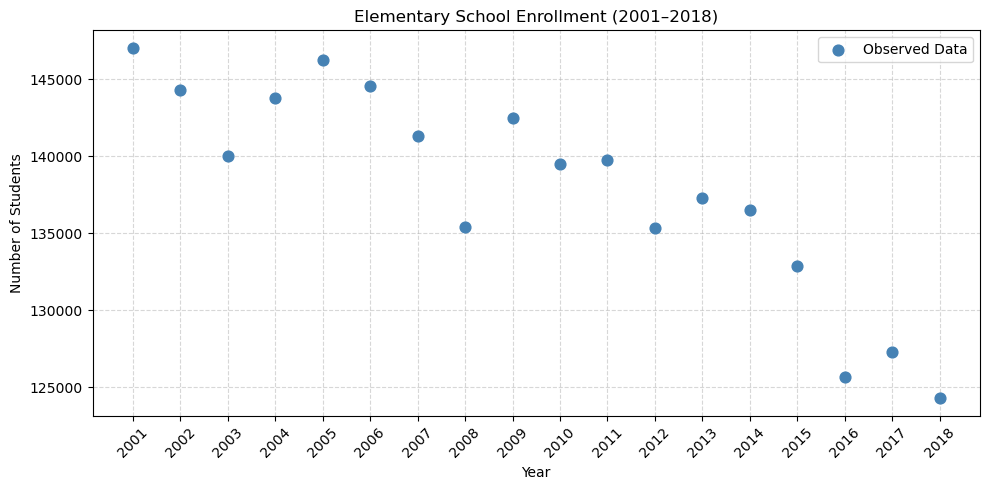

In [3]:
plt.figure(figsize=(10, 5))
plt.scatter(x, y, color='steelblue', s=60, zorder=5, label='Observed Data')
plt.xticks(x, years, rotation=45)
plt.xlabel('Year')
plt.ylabel('Number of Students')
plt.title('Elementary School Enrollment (2001–2018)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## Step 4: Linear Regression using `np.polyfit`



In [4]:
[a, b] = np.polyfit(x, y, 1)

print(f'Slope (a):     {a:.4f}')
print(f'Intercept (b): {b:.4f}')
print(f'\nRegression equation: y = {a:.2f}·x + {b:.2f}')

Slope (a):     -1142.0557
Intercept (b): 148817.5294

Regression equation: y = -1142.06·x + 148817.53


## Step 5: Plot Regression Line Over Observed Data

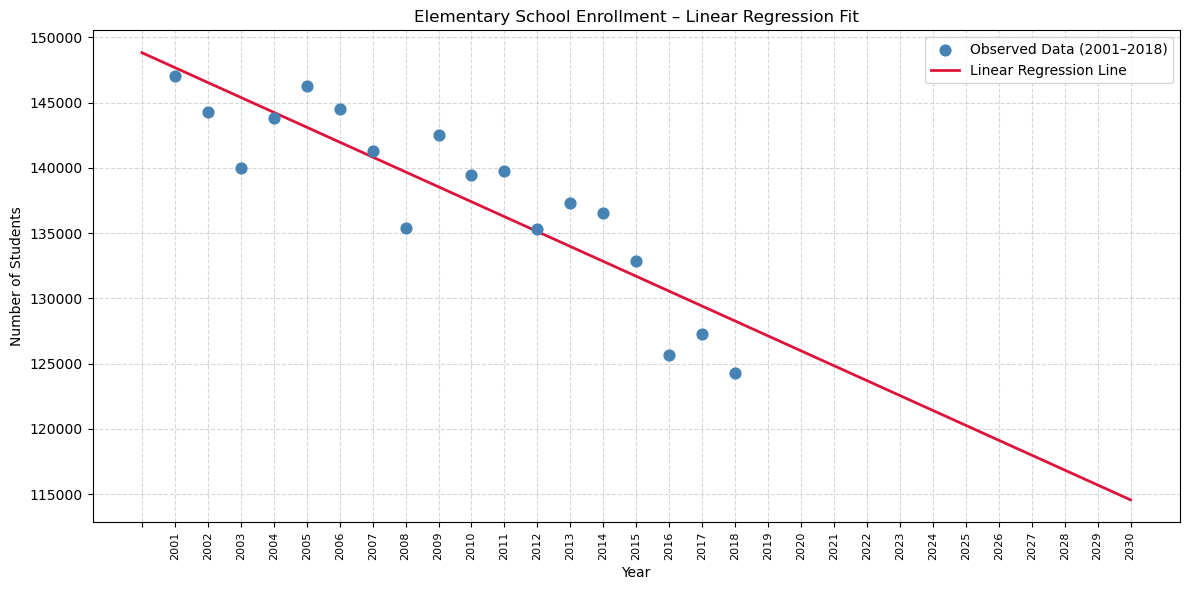

In [5]:
x_line = np.array([0, 30])
y_line = a * x_line + b

plt.figure(figsize=(12, 6))
plt.scatter(x, y, color='steelblue', s=60, zorder=5, label='Observed Data (2001–2018)')
plt.plot(x_line, y_line, color='crimson', linewidth=2, label='Linear Regression Line')
plt.xticks(range(0, 31, 1),
           ['' if i == 0 else str(2000 + i) for i in range(0, 31)],
           rotation=90, fontsize=8)
plt.xlabel('Year')
plt.ylabel('Number of Students')
plt.title('Elementary School Enrollment – Linear Regression Fit')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## Step 6: Predict Enrollment for 2025 and 2030



In [6]:
x_2025 = 2025 - 2000   # = 25
x_2030 = 2030 - 2000   # = 30

pred_2025 = a * x_2025 + b
pred_2030 = a * x_2030 + b

print(f'Predicted enrollment in 2025 (x={x_2025}): {pred_2025:,.0f} students')
print(f'Predicted enrollment in 2030 (x={x_2030}): {pred_2030:,.0f} students')

Predicted enrollment in 2025 (x=25): 120,266 students
Predicted enrollment in 2030 (x=30): 114,556 students


## Step 7: Full Visualization with Predictions Highlighted

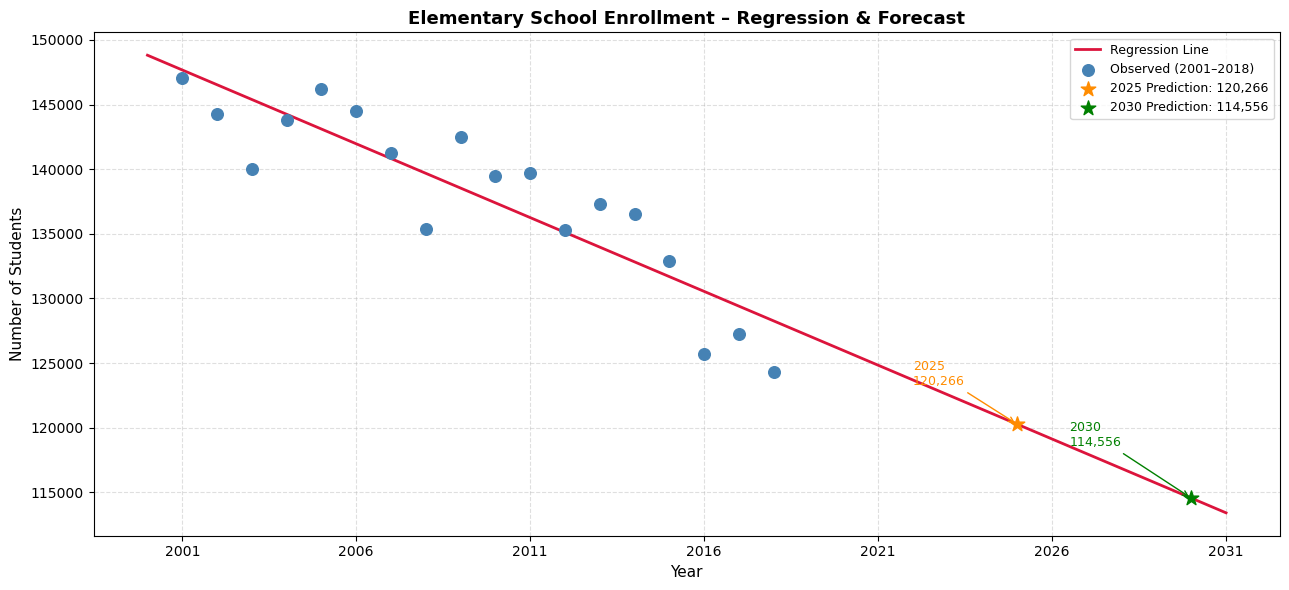

In [7]:
fig, ax = plt.subplots(figsize=(13, 6))

# Regression line
x_line = np.linspace(0, 31, 200)
y_line = a * x_line + b
ax.plot(x_line, y_line, color='crimson', linewidth=2, label='Regression Line', zorder=3)

# Observed data
ax.scatter(x, y, color='steelblue', s=70, zorder=5, label='Observed (2001–2018)')

# Prediction points
ax.scatter([x_2025], [pred_2025], color='darkorange', s=120, zorder=6,
           marker='*', label=f'2025 Prediction: {pred_2025:,.0f}')
ax.scatter([x_2030], [pred_2030], color='green', s=120, zorder=6,
           marker='*', label=f'2030 Prediction: {pred_2030:,.0f}')

# Annotation arrows
ax.annotate(f'2025\n{pred_2025:,.0f}',
            xy=(x_2025, pred_2025), xytext=(x_2025 - 3, pred_2025 + 3000),
            arrowprops=dict(arrowstyle='->', color='darkorange'),
            fontsize=9, color='darkorange')
ax.annotate(f'2030\n{pred_2030:,.0f}',
            xy=(x_2030, pred_2030), xytext=(x_2030 - 3.5, pred_2030 + 4000),
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=9, color='green')

# Tick labels every 5 years in actual year format
tick_positions = list(range(1, 32, 5))
tick_labels = [str(2000 + i) for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Number of Students', fontsize=11)
ax.set_title('Elementary School Enrollment – Regression & Forecast', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()